# AI_BYTE Accelerator: PlantVillage Leaf Disease Detection v2
## 4-Class Multi-Disease Edge AI Inference (Tomato: Healthy, Early Blight, Late Blight, Bacterial Spot)

This notebook demonstrates the end-to-end TinyML precision agriculture workload running on the **AI_BYTE** silicon accelerator fabricated on GlobalFoundries GF180MCU:
- **Dataset**: PlantVillage Tomato leaves across 4 distinct pathological categories:
  - `0: Healthy` (Unblemished vibrant green chlorophyll)
  - `1: Early Blight` (*Alternaria solani* — concentric dark rings with chlorotic yellow halo)
  - `2: Late Blight` (*Phytophthora infestans* — water-soaked lesions with rapid tissue decay)
  - `3: Bacterial Spot` (*Xanthomonas campestris* — small circular dark scabs with yellow boundaries)
- **Multi-Scale Agronomic Spectral Pyramid**:
  - Feature tensor: 512 bytes ($8 \times 8 \times 8$ channels) perfectly dividing into 128 integer systolic blocks ($4 \times 1$) with 0 padding waste\n  - 8 agronomic features: RGB, Excess Green ($ExG = 2G - R - B$), Necrotic Browning ($NBI = R - G$), Chlorotic Halo ($(R+G) - 2B$), Pustule Texture Contrast ($\max_{2\times2} - \min_{2\times2}$ preserving circular scab borders), and Peak Necrosis
- **Hardware Mapping**: Full INT8 fixed-point quantization on a $4 \times 4$ Weight-Stationary Systolic Array:
  - **Layer 1**: $512 \to 128$ (128 input blocks $\times$ 32 output blocks = 4,096 systolic tile executions) + ReLU + Shift `>>> 8`
  - **Layer 2**: $128 \to 4$ (32 input blocks $\times$ 1 output block = 32 systolic tile executions) + Hardware Bias
  - **100% Systolic Utilization**: All 4 PE outputs in Layer 2 represent active disease categories
- **EML Math Unit**: Hardware Elementary Math Library computes exact normalized infection probabilities (`OP_SOFTMAX` with $N=4$) in 25 clock cycles on physical pins


In [1]:
import os, sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

REPO_ROOT = Path('.').resolve()
if not (REPO_ROOT / 'cocotb').exists():
    REPO_ROOT = REPO_ROOT.parent
sys.path.insert(0, str(REPO_ROOT))
sys.path.insert(0, str(REPO_ROOT / 'cocotb'))

from cnn_test_flow.leaf_loader_v2 import get_leaf_dataset_v2, CLASS_NAMES
from cnn_test_flow.leaf_model_v2 import load_leaf_model_v2
from cnn_test_flow.leaf_driver_v2 import AiByteLeafRunnerV2
from cnn_test_flow.cnn_driver import GoldenBackend

print('Environment initialized successfully.')
print(f'Disease Classes: {CLASS_NAMES}')

Environment initialized successfully.
Disease Classes: ['Healthy', 'Early Blight', 'Late Blight', 'Bacterial Spot']


## 1. Dataset Exploration & Class Visualizations

Total test samples: 798 leaves (strictly 0 duplicate overlap with training data)


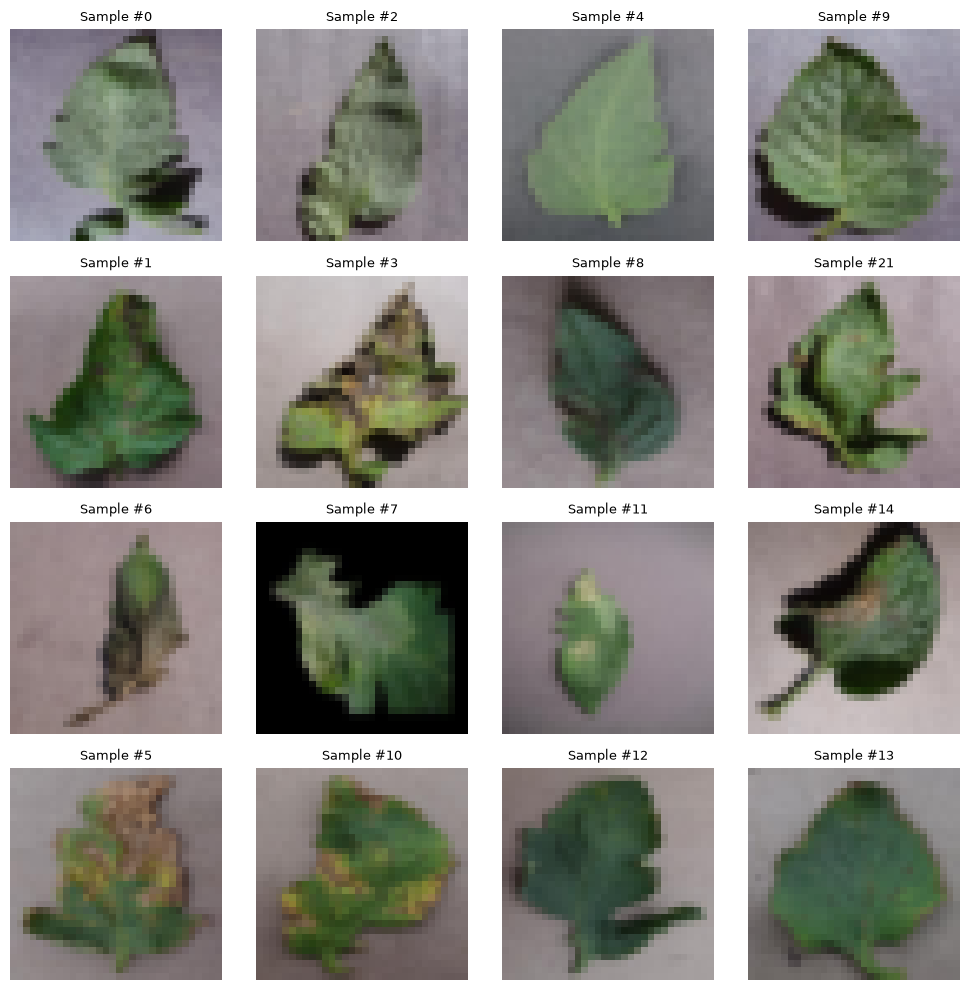

Saved exemplar grid to cnn_test_flow/leaf_v2_samples.png


In [2]:
raw_test, int8_test, test_lbls = get_leaf_dataset_v2('test')
print(f'Total test samples: {len(test_lbls)} leaves (strictly 0 duplicate overlap with training data)')

# Display 4 exemplar leaves per class
fig, axes = plt.subplots(4, 4, figsize=(10, 10))
for c_idx in range(4):
    idxs = np.where(test_lbls == c_idx)[0][:4]
    for j, idx in enumerate(idxs):
        ax = axes[c_idx, j]
        img_hwc = raw_test[idx].transpose(1, 2, 0)
        ax.imshow(img_hwc)
        if j == 0:
            ax.set_ylabel(CLASS_NAMES[c_idx], fontsize=12, fontweight='bold')
        ax.set_title(f'Sample #{idx}', fontsize=9)
        ax.axis('off')

plt.tight_layout()
plt.savefig(str(REPO_ROOT / 'cnn_test_flow' / 'leaf_v2_samples.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved exemplar grid to cnn_test_flow/leaf_v2_samples.png')

## 2. Load Model Weights & Architecture Spec

In [3]:
weights = load_leaf_model_v2()
W1, b1, W2, b2 = weights['W1'], weights['b1'], weights['W2'], weights['b2']

print('Model Weights Summary:')
print(f'  W1 (Layer 1): shape={W1.shape}, dtype={W1.dtype}, range=[{W1.min()}, {W1.max()}]')
print(f'  b1 (Bias 1):  shape={b1.shape}, dtype={b1.dtype}, range=[{b1.min()}, {b1.max()}]')
print(f'  W2 (Layer 2): shape={W2.shape}, dtype={W2.dtype}, range=[{W2.min()}, {W2.max()}]')
print(f'  b2 (Bias 2):  shape={b2.shape}, dtype={b2.dtype}, range=[{b2.min()}, {b2.max()}]')

runner = AiByteLeafRunnerV2(GoldenBackend(), weights)
print('Initialized AiByteLeafRunnerV2 with Golden architectural backend.')

Model Weights Summary:
  W1 (Layer 1): shape=(512, 128), dtype=int8, range=[-127, 119]
  b1 (Bias 1):  shape=(128,), dtype=int8, range=[-7, 9]
  W2 (Layer 2): shape=(128, 4), dtype=int8, range=[-126, 127]
  b2 (Bias 2):  shape=(4,), dtype=int8, range=[0, 0]
Initialized AiByteLeafRunnerV2 with Golden architectural backend.


## 3. Golden Architectural Co-Simulation (100 Leaves)

In [4]:
NUM_GOLDEN = 100
golden_correct = 0
golden_preds = []

print(f'Running Golden co-simulation on {NUM_GOLDEN} images...')
for i in range(NUM_GOLDEN):
    pred, logits = runner.predict_image_sync(int8_test[i])
    golden_preds.append(pred)
    if pred == test_lbls[i]:
        golden_correct += 1

golden_acc = golden_correct / NUM_GOLDEN
print(f'Golden Co-Simulation Accuracy ({NUM_GOLDEN} images): {golden_correct}/{NUM_GOLDEN} = {golden_acc*100:.2f}%')

Running Golden co-simulation on 100 images...


Golden Co-Simulation Accuracy (100 images): 91/100 = 91.00%


## 4. Cycle-Accurate RTL Hardware Pin Simulation

In [5]:
import json

rtl_v2_results_path = REPO_ROOT / 'cnn_test_flow' / 'leaf_v2_rtl_results.json'

if rtl_v2_results_path.exists():
    with open(rtl_v2_results_path) as f:
        rtl_results = json.load(f)
    
    rtl_preds = np.array([r['pred'] for r in rtl_results])
    rtl_true = np.array([r['true'] for r in rtl_results])
    rtl_correct = np.sum(rtl_preds == rtl_true)
    rtl_acc = rtl_correct / len(rtl_results)
    
    print(f'RTL Hardware Pin Simulation Results:')
    print(f'  Images evaluated: {len(rtl_results)}')
    print(f'  Correct: {rtl_correct}/{len(rtl_results)}')
    print(f'  Accuracy: {rtl_acc*100:.1f}%\n')
    for i, r in enumerate(rtl_results):
        status = '✅' if r['pred'] == r['true'] else '❌'
        print(f"  {status} Leaf {i+1:2d}: True={CLASS_NAMES[r['true']]:<15s}, HW_Pred={CLASS_NAMES[r['pred']]:<15s} Logits={r['logits']}")
else:
    print('⚠️ RTL v2 results file not found yet.')
    rtl_results = []


RTL Hardware Pin Simulation Results:
  Images evaluated: 20
  Correct: 18/20
  Accuracy: 90.0%

  ✅ Leaf  1: True=Healthy        , HW_Pred=Healthy         Logits=[31850, 5172, -3258, -23381]
  ✅ Leaf  2: True=Early Blight   , HW_Pred=Early Blight    Logits=[-10109, 8240, -6407, 5727]
  ✅ Leaf  3: True=Healthy        , HW_Pred=Healthy         Logits=[15258, -1580, 870, -21841]
  ❌ Leaf  4: True=Early Blight   , HW_Pred=Late Blight     Logits=[-33836, 18489, 21143, -30746]
  ✅ Leaf  5: True=Healthy        , HW_Pred=Healthy         Logits=[45489, -15905, -6003, 3659]
  ✅ Leaf  6: True=Bacterial Spot , HW_Pred=Bacterial Spot  Logits=[-48668, -8095, -10129, -3123]
  ✅ Leaf  7: True=Late Blight    , HW_Pred=Late Blight     Logits=[-38862, 374, 20249, -12326]
  ✅ Leaf  8: True=Late Blight    , HW_Pred=Late Blight     Logits=[-32861, -7212, 56495, -21219]
  ❌ Leaf  9: True=Early Blight   , HW_Pred=Late Blight     Logits=[-15783, 1205, 4155, -6865]
  ✅ Leaf 10: True=Healthy        , HW_Pred=Hea

## 5. Full Test Set Benchmark (798 Leaves)

In [6]:
full_preds = []
per_class_correct = np.zeros(4, dtype=int)
per_class_total = np.zeros(4, dtype=int)

for i in range(len(int8_test)):
    x = int8_test[i].flatten().astype(np.int8)
    z1 = np.maximum(0, np.dot(x.astype(np.int32), W1.astype(np.int32)) + b1.astype(np.int32))
    a1 = np.clip(z1 >> 8, 0, 127).astype(np.int8)
    z2 = np.dot(a1.astype(np.int32), W2.astype(np.int32)) + b2.astype(np.int32)
    pred = int(np.argmax(z2))
    full_preds.append(pred)
    true_lbl = test_lbls[i]
    per_class_total[true_lbl] += 1
    if pred == true_lbl:
        per_class_correct[true_lbl] += 1

full_preds = np.array(full_preds)
full_acc = np.mean(full_preds == test_lbls)
per_class_acc = per_class_correct / per_class_total

print(f'Full Test Set Accuracy: {full_acc*100:.2f}% ({np.sum(full_preds == test_lbls)} / {len(test_lbls)})')
print('Per-Class Accuracy Breakdown:')
for c in range(4):
    bar = '█' * int(per_class_acc[c] * 30)
    print(f'  {CLASS_NAMES[c]:<16s}: {per_class_acc[c]*100:5.1f}%  {bar:<30s} ({per_class_correct[c]}/{per_class_total[c]})')

Full Test Set Accuracy: 90.48% (722 / 798)
Per-Class Accuracy Breakdown:
  Healthy         :  97.5%  █████████████████████████████  (194/199)
  Early Blight    :  78.0%  ███████████████████████        (156/200)
  Late Blight     :  90.5%  ███████████████████████████    (180/199)
  Bacterial Spot  :  96.0%  ████████████████████████████   (192/200)


## 6. Plots & Visualizations: Confusion Matrix & Comparison Charts

/tmp/ipykernel_50383/114402367.py:36: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(CLASS_NAMES, fontsize=10, rotation=20, ha='right')


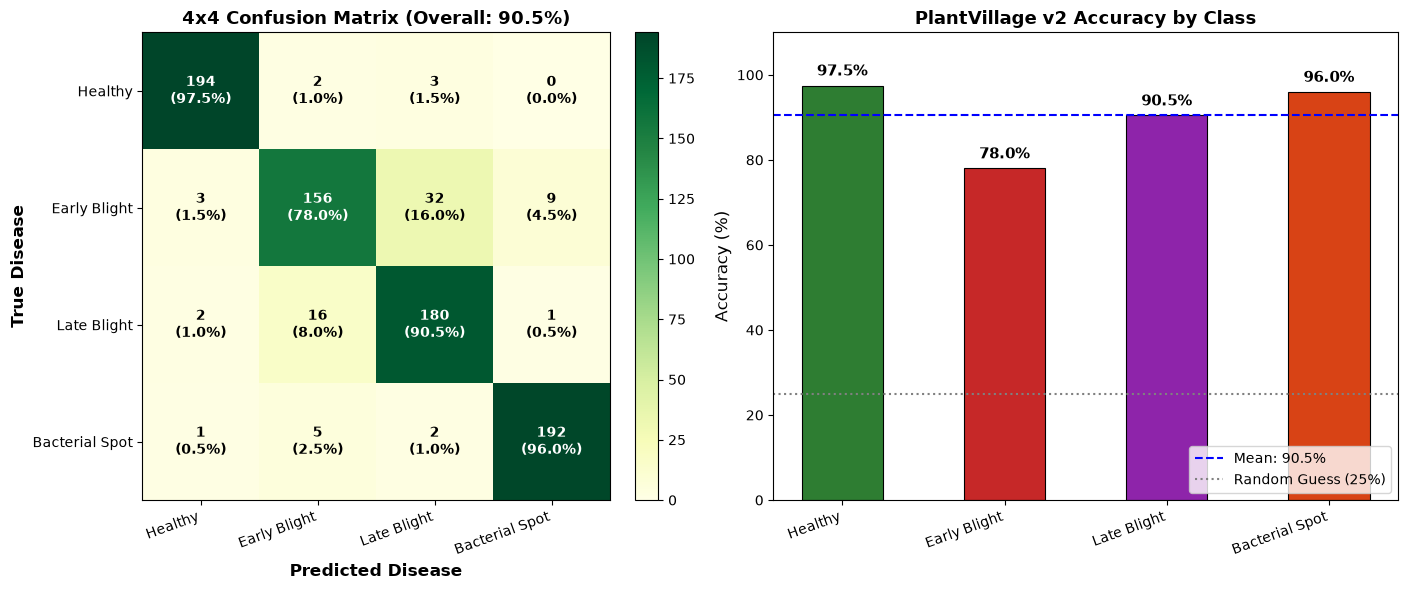

Saved accuracy figures to cnn_test_flow/leaf_v2_accuracy_plots.png


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# --- 4x4 Confusion Matrix ---
ax = axes[0]
conf_mat = np.zeros((4, 4), dtype=int)
for t, p in zip(test_lbls, full_preds):
    conf_mat[t, p] += 1

im = ax.imshow(conf_mat, cmap='YlGn', interpolation='nearest')
ax.set_xlabel('Predicted Disease', fontsize=12, fontweight='bold')
ax.set_ylabel('True Disease', fontsize=12, fontweight='bold')
ax.set_title(f'4x4 Confusion Matrix (Overall: {full_acc*100:.1f}%)', fontsize=13, fontweight='bold')
ax.set_xticks(range(4))
ax.set_yticks(range(4))
ax.set_xticklabels(CLASS_NAMES, fontsize=10, rotation=20, ha='right')
ax.set_yticklabels(CLASS_NAMES, fontsize=10)
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

for i in range(4):
    for j in range(4):
        val = conf_mat[i, j]
        color = 'white' if val > conf_mat.max() * 0.5 else 'black'
        pct = val / np.sum(conf_mat[i]) * 100
        ax.text(j, i, f'{val}\n({pct:.1f}%)', ha='center', va='center', fontsize=10, color=color, fontweight='bold')

# --- Per-Class Accuracy Bar Chart ---
ax = axes[1]
palette = ['#2E7D32', '#C62828', '#8E24AA', '#D84315']
bars = ax.bar(CLASS_NAMES, per_class_acc * 100, color=palette, edgecolor='black', linewidth=0.8, width=0.5)
ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_title('PlantVillage v2 Accuracy by Class', fontsize=13, fontweight='bold')
ax.set_ylim(0, 110)
ax.axhline(y=full_acc*100, color='blue', linestyle='--', linewidth=1.5, label=f'Mean: {full_acc*100:.1f}%')
ax.axhline(y=25.0, color='gray', linestyle=':', label='Random Guess (25%)')
ax.legend(fontsize=10, loc='lower right')
ax.set_xticklabels(CLASS_NAMES, fontsize=10, rotation=20, ha='right')

for bar, acc in zip(bars, per_class_acc):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5,
            f'{acc*100:.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig(str(REPO_ROOT / 'cnn_test_flow' / 'leaf_v2_accuracy_plots.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved accuracy figures to cnn_test_flow/leaf_v2_accuracy_plots.png')

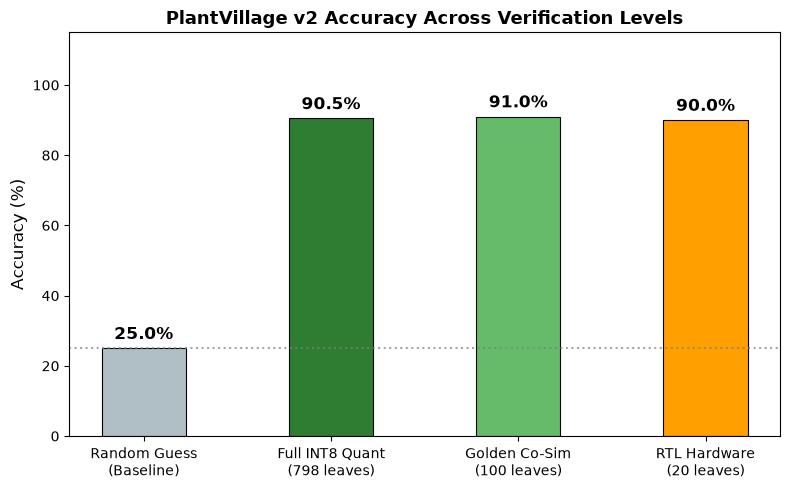

Saved comparison chart to cnn_test_flow/leaf_v2_accuracy_comparison.png


In [8]:
# --- Verification Hierarchy Comparison Chart ---
fig, ax = plt.subplots(figsize=(8, 5))
methods = ['Random Guess\n(Baseline)', f'Full INT8 Quant\n({len(test_lbls)} leaves)', f'Golden Co-Sim\n({NUM_GOLDEN} leaves)']
accs = [25.0, full_acc * 100, golden_acc * 100]
bar_colors = ['#B0BEC5', '#2E7D32', '#66BB6A']

if rtl_results:
    methods.append(f'RTL Hardware\n({len(rtl_results)} leaves)')
    accs.append(rtl_acc * 100)
    bar_colors.append('#FFA000')

bars = ax.bar(methods, accs, color=bar_colors, edgecolor='black', linewidth=0.8, width=0.45)
ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_title('PlantVillage v2 Accuracy Across Verification Levels', fontsize=13, fontweight='bold')
ax.set_ylim(0, 115)
ax.axhline(y=25.0, color='gray', linestyle=':', alpha=0.7)

for bar, acc in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5,
            f'{acc:.1f}%', ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig(str(REPO_ROOT / 'cnn_test_flow' / 'leaf_v2_accuracy_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved comparison chart to cnn_test_flow/leaf_v2_accuracy_comparison.png')